In [18]:
import warnings
warnings.filterwarnings("ignore")

import os, gc
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report, f1_score, roc_auc_score, roc_curve, auc)

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import timm
import subprocess

import torchaudio
import torchaudio.transforms as AT

In [19]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

Device: cuda


In [20]:
import shutil
shutil.rmtree('/kaggle/working/spectrograms', ignore_errors=True)
print("Cache cleared")

Cache cleared


In [21]:
base = Path('/kaggle/input/datasets/mohammedabdeldayem/the-fake-or-real-dataset/for-2sec/for-2seconds')

file_names, labels = [], []   
for split in ['training', 'validation', 'testing']:
    for label in ['real', 'fake']:
        folder = base / split / label
        if not folder.exists():
            continue
        for f in folder.glob('*.wav'):
            file_names.append(str(f))
            labels.append(label)

df = pd.DataFrame({'file_name': file_names, 'label': labels})  

df['stem'] = df['file_name'].apply(lambda x: Path(x).stem)
df = df.drop_duplicates(subset='stem').reset_index(drop=True)

print(f"After dedup: {len(df)} samples")
print(df['label'].value_counts())

train_df, temp_df = train_test_split(df,test_size=0.2, stratify=df['label'],random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5,  stratify=temp_df['label'], random_state=42)

overlap_tv = set(train_df['stem']) & set(val_df['stem'])
overlap_tt = set(train_df['stem']) & set(test_df['stem'])
print(f"Overlap train∩val: {len(overlap_tv)}  train∩test: {len(overlap_tt)}")  

train_df = train_df.copy(); train_df['split'] = 'training'
val_df = val_df.copy(); val_df['split']   = 'validation'
test_df = test_df.copy(); test_df['split']  = 'testing'

df_all = pd.concat([train_df, val_df, test_df]).reset_index(drop=True)
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

After dedup: 17291 samples
label
real    8766
fake    8525
Name: count, dtype: int64
Overlap train∩val: 0  train∩test: 0
Train: 13832 | Val: 1729 | Test: 1730


In [22]:
train_df['split'] = 'training'
val_df['split'] = 'validation'
test_df['split'] = 'testing'
df_all = pd.concat([train_df, val_df, test_df]).reset_index(drop=True)

In [23]:
SPEC_DIR = Path('/kaggle/working/spectrograms')
SR = 22050
DURATION = 2
N_MELS = 128
HOP_LENGTH = 512

def audio_to_spectrogram(file_path, out_path):
    try:
        y, sr = librosa.load(file_path, sr=SR, duration=DURATION)
        target_len = SR * DURATION
        if len(y) < target_len:
            y = np.pad(y, (0, target_len - len(y)))
        mel = librosa.feature.melspectrogram(y=y, sr=SR, n_mels=N_MELS, hop_length=HOP_LENGTH)
        mel_db = librosa.power_to_db(mel, ref=np.max)
        fig, ax = plt.subplots(figsize=(2.24, 2.24), dpi=100)
        librosa.display.specshow(mel_db, sr=SR, hop_length=HOP_LENGTH,
                                 x_axis=None, y_axis=None, ax=ax)
        ax.set_axis_off()
        plt.savefig(out_path, bbox_inches='tight', pad_inches=0)
        plt.close(fig)
        return True
    except:
        return False

for split in ['training', 'validation', 'testing']:
    for label in ['real', 'fake']:
        (SPEC_DIR / split / label).mkdir(parents=True, exist_ok=True)

failed = 0
for _, row in tqdm(df_all.iterrows(), total=len(df_all), desc="Extracting spectrograms"):
    out_path = SPEC_DIR / row['split'] / row['label'] / (Path(row['file_name']).stem + '.png')
    if out_path.exists():
        continue
    if not audio_to_spectrogram(row['file_name'], out_path):
        failed += 1

print(f"Done. Failed: {failed}")
for split in ['training', 'validation', 'testing']:
    for label in ['real', 'fake']:
        count = len(list((SPEC_DIR / split / label).glob('*.png')))
        print(f"  {split}/{label}: {count}")

Extracting spectrograms: 100%|██████████| 17291/17291 [19:43<00:00, 14.62it/s]  


Done. Failed: 0
  training/real: 7012
  training/fake: 6820
  validation/real: 877
  validation/fake: 852
  testing/real: 877
  testing/fake: 853


In [24]:
file_names2, labels2, splits2 = [], [], []

for split in ['training', 'validation', 'testing']:
    for label in ['real', 'fake']:
        for f in (SPEC_DIR / split / label).glob('*.png'):
            file_names2.append(str(f))
            labels2.append(label)
            splits2.append(split)

spec_df = pd.DataFrame({'file_name': file_names2, 'label': labels2, 'split': splits2})
print("Spectrogram dataset:", spec_df.shape)
print(spec_df['label'].value_counts())

le = LabelEncoder()
spec_df['label_enc'] = le.fit_transform(spec_df['label'])
print("Classes:", le.classes_)

train_df = spec_df[spec_df['split'] == 'training'].reset_index(drop=True)
val_df = spec_df[spec_df['split'] == 'validation'].reset_index(drop=True)
test_df = spec_df[spec_df['split'] == 'testing'].reset_index(drop=True)

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

Spectrogram dataset: (17291, 3)
label
real    8766
fake    8525
Name: count, dtype: int64
Classes: ['fake' 'real']
Train: 13832, Val: 1729, Test: 1730


In [25]:
IMG_SIZE = 224

class SpectrogramDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img = Image.open(self.df.loc[idx, 'file_name']).convert('RGB')
        label = self.df.loc[idx, 'label_enc']
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(label, dtype=torch.long)


train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.1, scale=(0.02, 0.08))
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_dataset = SpectrogramDataset(train_df, train_transform)
val_dataset = SpectrogramDataset(val_df,   val_transform)
test_dataset = SpectrogramDataset(test_df,  val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train: {len(train_loader)} batches | Val: {len(val_loader)} | Test: {len(test_loader)}")

Train: 433 batches | Val: 55 | Test: 55


In [41]:
train_stems = set(spec_df[spec_df['split']=='training']['file_name'].apply(lambda x: Path(x).stem))
val_stems = set(spec_df[spec_df['split']=='validation']['file_name'].apply(lambda x: Path(x).stem))
test_stems = set(spec_df[spec_df['split']=='testing']['file_name'].apply(lambda x: Path(x).stem))

print("spec_df overlap train∩val:", len(train_stems & val_stems))
print("spec_df overlap train∩test:", len(train_stems & test_stems))
print(spec_df['split'].value_counts())

spec_df overlap train∩val: 0
spec_df overlap train∩test: 0
split
training      13832
testing        1730
validation     1729
Name: count, dtype: int64


In [26]:
class AudioDeepfakeDetector(nn.Module):
    def __init__(self, num_classes=2, dropout=0.4):
        super().__init__()
        self.backbone = timm.create_model(
            'efficientnet_b4',
            pretrained=True,
            num_classes=0,
            global_pool='avg'
        )
        feat_dim = self.backbone.num_features  

        self.head = nn.Sequential(
            nn.BatchNorm1d(feat_dim),
            nn.Dropout(dropout),
            nn.Linear(feat_dim, 512),
            nn.GELU(),
            nn.BatchNorm1d(512),
            nn.Dropout(dropout * 0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.head(self.backbone(x))


model = AudioDeepfakeDetector(num_classes=2).to(device)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Parameters: 18,472,266


In [27]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        return (self.alpha * (1 - pt) ** self.gamma * ce_loss).mean()

criterion = FocalLoss(alpha=1, gamma=2)

optimizer = optim.AdamW([
    {'params': model.backbone.parameters(), 'lr': 2e-5},
    {'params': model.head.parameters(),     'lr': 2e-4},
], weight_decay=1e-4)

EPOCHS = 10
SAVE_PATH = '/kaggle/working/best_audio_model.pth'

scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr = [2e-5, 2e-4],
    steps_per_epoch = len(train_loader),
    epochs = EPOCHS,
    pct_start = 0.15,
    anneal_strategy = 'cos'
)

In [28]:
overlap = set(Path(f).stem for f in train_df['file_name']) & \
          set(Path(f).stem for f in val_df['file_name'])
print("Stem overlap train∩val:", len(overlap))

overlap2 = set(Path(f).stem for f in train_df['file_name']) & \
           set(Path(f).stem for f in test_df['file_name'])
print("Stem overlap train∩test:", len(overlap2))

Stem overlap train∩val: 0
Stem overlap train∩test: 0


In [29]:
def train_epoch(model, loader, optimizer, criterion, scheduler, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels in tqdm(loader, desc="Train", leave=False):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return total_loss / len(loader), correct / total


def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Eval", leave=False):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)
    return total_loss / len(loader), correct / total


best_val_acc = 0
patience, no_improve = 5, 0

for epoch in range(EPOCHS):
    tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion, scheduler, device)
    vl_loss, vl_acc = eval_epoch(model, val_loader, criterion, device)

    print(f"Epoch {epoch+1:02d}/{EPOCHS} | "
          f"Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | "
          f"Val Loss: {vl_loss:.4f} Acc: {vl_acc:.4f}")

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        no_improve   = 0
        torch.save(model.state_dict(), SAVE_PATH)
        print(f"Saved (val_acc={vl_acc:.4f})")
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f" Early stopping at epoch {epoch+1}")
            break

print(f"\n Best Val Accuracy: {best_val_acc:.4f}")

Epoch 01/10 | Train Loss: 0.1662 Acc: 0.7402 | Val Loss: 0.0823 Acc: 0.8785
Saved (val_acc=0.8785)


Epoch 02/10 | Train Loss: 0.1035 Acc: 0.8535 | Val Loss: 0.0565 Acc: 0.9086
Saved (val_acc=0.9086)


Epoch 03/10 | Train Loss: 0.0609 Acc: 0.9107 | Val Loss: 0.0343 Acc: 0.9503
Saved (val_acc=0.9503)


Epoch 04/10 | Train Loss: 0.0446 Acc: 0.9340 | Val Loss: 0.0227 Acc: 0.9722
Saved (val_acc=0.9722)


Epoch 05/10 | Train Loss: 0.0332 Acc: 0.9515 | Val Loss: 0.0161 Acc: 0.9815
Saved (val_acc=0.9815)


Epoch 06/10 | Train Loss: 0.0279 Acc: 0.9626 | Val Loss: 0.0136 Acc: 0.9838
Saved (val_acc=0.9838)


Epoch 07/10 | Train Loss: 0.0244 Acc: 0.9673 | Val Loss: 0.0121 Acc: 0.9873
Saved (val_acc=0.9873)


Epoch 08/10 | Train Loss: 0.0225 Acc: 0.9675 | Val Loss: 0.0126 Acc: 0.9896
Saved (val_acc=0.9896)


Epoch 09/10 | Train Loss: 0.0216 Acc: 0.9701 | Val Loss: 0.0119 Acc: 0.9873


Epoch 10/10 | Train Loss: 0.0214 Acc: 0.9718 | Val Loss: 0.0109 Acc: 0.9896

 Best Val Accuracy: 0.9896


In [39]:
print(val_df['label'].value_counts())

label
real    877
fake    852
Name: count, dtype: int64


In [40]:
for split in ['training', 'validation', 'testing']:
    for label in ['real', 'fake']:
        count = len(list((SPEC_DIR / split / label).glob('*.png')))
        print(f"  {split}/{label}: {count}")

  training/real: 7012
  training/fake: 6820
  validation/real: 877
  validation/fake: 852
  testing/real: 877
  testing/fake: 853


In [30]:
model.load_state_dict(torch.load(SAVE_PATH))
model.eval()
print("Best audio model loaded")

Best audio model loaded


In [31]:
val_probs_list, val_labels_list = [], []
with torch.no_grad():
    for images, labels in tqdm(val_loader, desc="Val threshold search"):
        outputs = model(images.to(device))
        probs = torch.softmax(outputs, dim=1)[:, 1] 
        val_probs_list.extend(probs.cpu().numpy())
        val_labels_list.extend(labels.numpy())

val_probs_arr = np.array(val_probs_list)
val_labels_arr = np.array(val_labels_list)

thresholds = np.linspace(0.1, 0.9, 81)
best_thresh, best_f1 = 0.5, 0
for t in thresholds:
    preds = (val_probs_arr >= t).astype(int) 
    f1 = f1_score(val_labels_arr, preds, pos_label=0) 
    if f1 > best_f1:
        best_f1, best_thresh = f1, t

print(f"Optimal threshold: {best_thresh:.2f}  (val fake-F1: {best_f1:.4f})")

Val threshold search: 100%|██████████| 55/55 [00:07<00:00,  7.75it/s]

Optimal threshold: 0.49  (val fake-F1: 0.9900)


In [32]:
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        outputs = model(images.to(device))
        probs = torch.softmax(outputs, dim=1)[:, 1]
        all_preds.extend(outputs.argmax(1).cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

y_true = np.array(all_labels)
y_pred = np.array(all_preds)
y_probs = np.array(all_probs)
print("Inference complete")

Testing: 100%|██████████| 55/55 [00:07<00:00,  7.65it/s]

Inference complete


In [33]:
print(f"Accuracy : {accuracy_score(y_true, y_pred):.4f}")
print(f"F1 Score : {f1_score(y_true, y_pred, average='macro'):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_true, y_probs):.4f}")
print()
print(classification_report(y_true, y_pred, target_names=le.classes_))

Accuracy : 0.9861
F1 Score : 0.9861
ROC-AUC  : 0.9991

              precision    recall  f1-score   support

        fake       0.99      0.99      0.99       853
        real       0.99      0.99      0.99       877

    accuracy                           0.99      1730
   macro avg       0.99      0.99      0.99      1730
weighted avg       0.99      0.99      0.99      1730



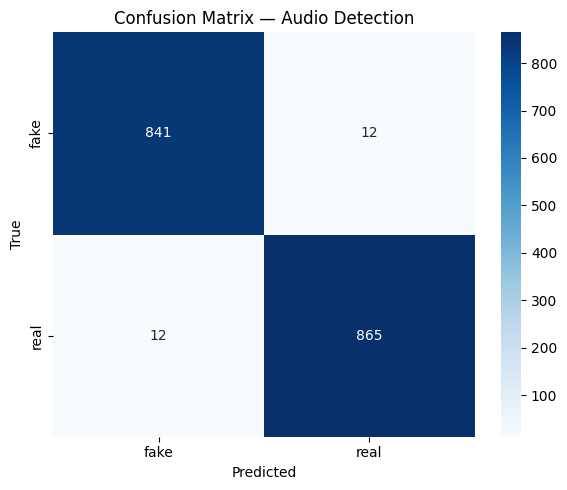

In [34]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted'); plt.ylabel('True')
plt.title('Confusion Matrix — Audio Detection')
plt.tight_layout()
plt.savefig('/kaggle/working/audio_confusion_matrix.png', dpi=120)
plt.show()

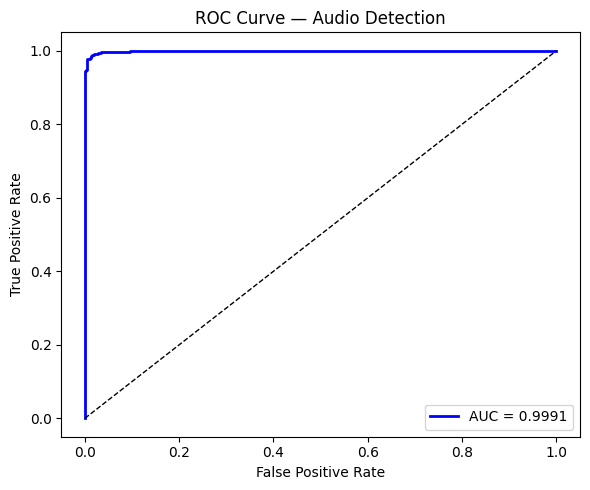

In [35]:
fpr, tpr, _ = roc_curve(y_true, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='Blue', lw=2, label=f'AUC = {roc_auc:.4f}')
plt.plot([0,1],[0,1],'k--', lw=1)
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Audio Detection'); plt.legend()
plt.tight_layout()
plt.savefig('/kaggle/working/audio_roc_curve.png', dpi=120)
plt.show()

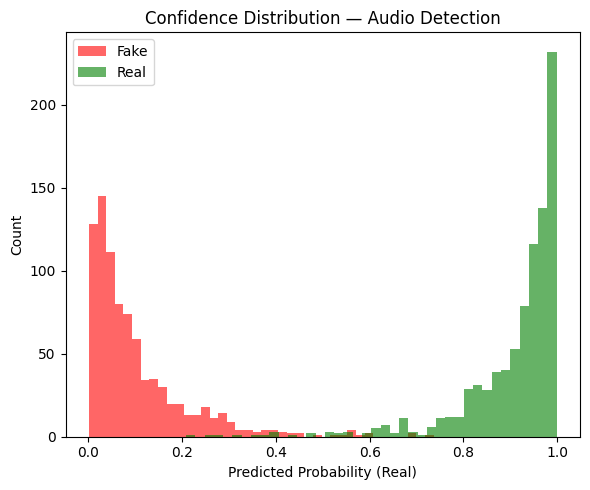

In [36]:
plt.figure(figsize=(6, 5))
plt.hist(y_probs[y_true == 0], bins=40, alpha=0.6, color='red',   label='Fake')
plt.hist(y_probs[y_true == 1], bins=40, alpha=0.6, color='green', label='Real')
plt.xlabel('Predicted Probability (Real)')
plt.ylabel('Count')
plt.title('Confidence Distribution — Audio Detection')
plt.legend()
plt.tight_layout()
plt.savefig('/kaggle/working/audio_confidence_dist.png', dpi=120)
plt.show()

Total misclassified: 24 / 1730


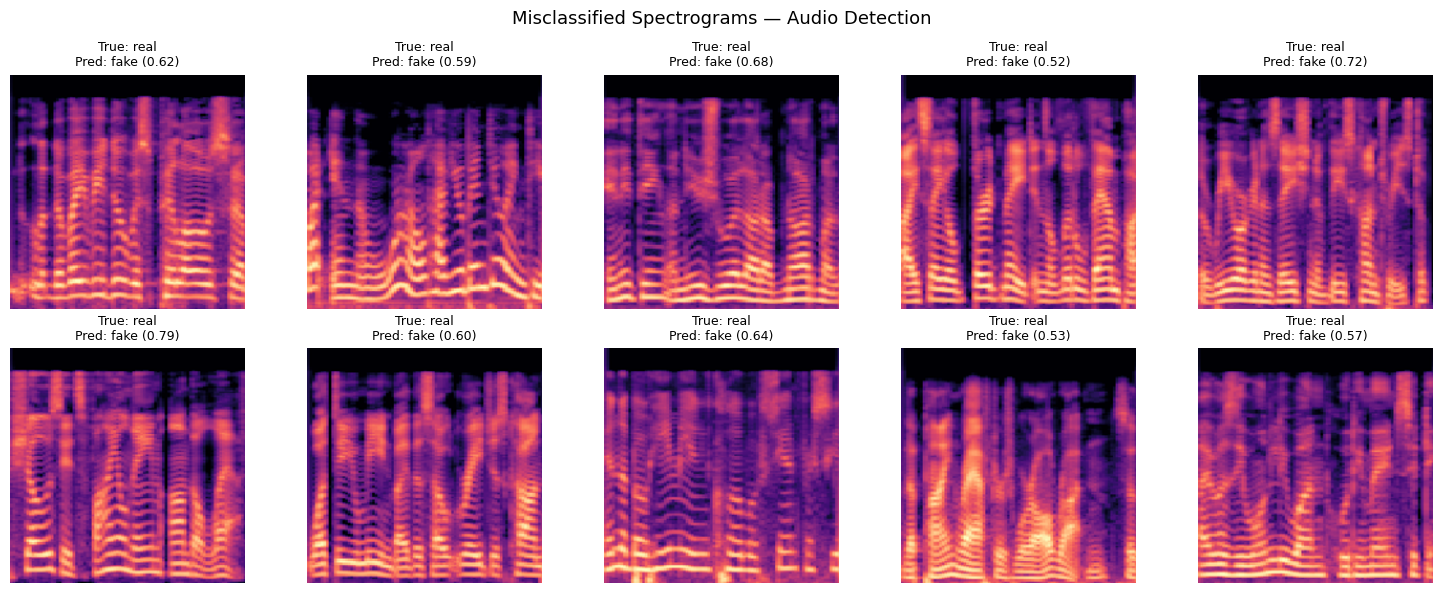

In [37]:
wrong_idx = np.where(y_pred != y_true)[0]
print(f"Total misclassified: {len(wrong_idx)} / {len(y_true)}")

n_show = min(10, len(wrong_idx))
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i, idx in enumerate(wrong_idx[:n_show]):
    img_path = test_df.iloc[idx]['file_name']
    img      = Image.open(img_path).convert('RGB').resize((224, 224))
    axes[i].imshow(img)
    true_label = le.classes_[y_true[idx]]
    pred_label = le.classes_[y_pred[idx]]
    conf = y_probs[idx] if y_pred[idx] == 1 else 1 - y_probs[idx]
    axes[i].set_title(f"True: {true_label}\nPred: {pred_label} ({conf:.2f})", fontsize=9)
    axes[i].axis('off')

for j in range(n_show, len(axes)):
    axes[j].axis('off')

plt.suptitle('Misclassified Spectrograms — Audio Detection', fontsize=13)
plt.tight_layout()
plt.savefig('/kaggle/working/audio_errors.png', dpi=120)
plt.show()

Default (0.50) F1  : 0.9861
Optimal (0.47) F1 : 0.9867


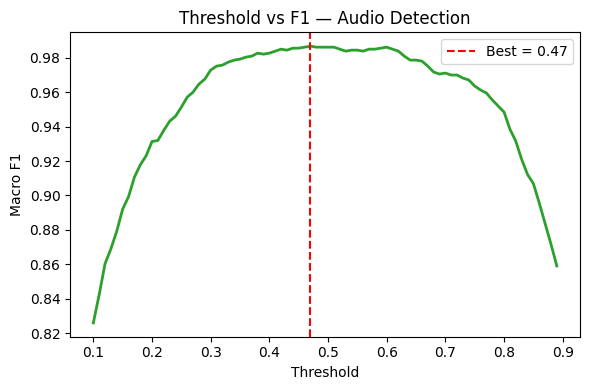

In [38]:
thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores  = [f1_score(y_true, (y_probs >= t).astype(int), average='macro') for t in thresholds]
best_t = thresholds[np.argmax(f1_scores)]

print(f"Default (0.50) F1  : {f1_score(y_true, (y_probs >= 0.50).astype(int), average='macro'):.4f}")
print(f"Optimal ({best_t:.2f}) F1 : {max(f1_scores):.4f}")

plt.figure(figsize=(6, 4))
plt.plot(thresholds, f1_scores, color='Green', lw=2)
plt.axvline(best_t, color='red', linestyle='--', label=f'Best = {best_t:.2f}')
plt.xlabel('Threshold'); plt.ylabel('Macro F1')
plt.title('Threshold vs F1 — Audio Detection'); plt.legend()
plt.tight_layout()
plt.savefig('/kaggle/working/audio_threshold.png', dpi=120)
plt.show()